In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import log_loss, mean_absolute_error

## Data Exploration and Initial Processing

### Loading and Initial Inspection

In [ ]:
train_path = "./data/AppML_InitialProject_train.h5"

data = pd.read_hdf(train_path)
variables = data.columns

[i for i in variables if 'truth' in i.lower()]

In [ ]:
data.describe()

# Display basic information
print(f"Dataset shape: {data.shape}")
print(f"Target distribution: {data['p_Truth_isElectron'].value_counts()}")

# Check for missing values
missing_values = df.isnull().sum()
print("Features with missing values:", missing_values[missing_values > 0])

### Separating Variables and Handling Missing Values

In [ ]:
# Decide on which variables to use for input (X) and what defines the label (Y):
input_variables = variables[(variables != 'p_Truth_isElectron') & (variables != 'p_Truth_Energy')]
                            
# classification
X = data[input_variables]
y_class = data["p_Truth_isElectron"]

# regression
X_reg   = X.loc[y_class==1]
y_reg   = data.loc[y_class==1, "p_Truth_Energy"]



X.shape, y_class.shape

In [ ]:

# # 3. Train/test split for internal evaluation
# Xc_train, Xc_val, yc_train, yc_val = train_test_split(X, y_class, test_size=0.2, stratify=y_class, random_state=42)
# Xr_train, Xr_val, yr_train, yr_val = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


## 2. Correlation Analysis


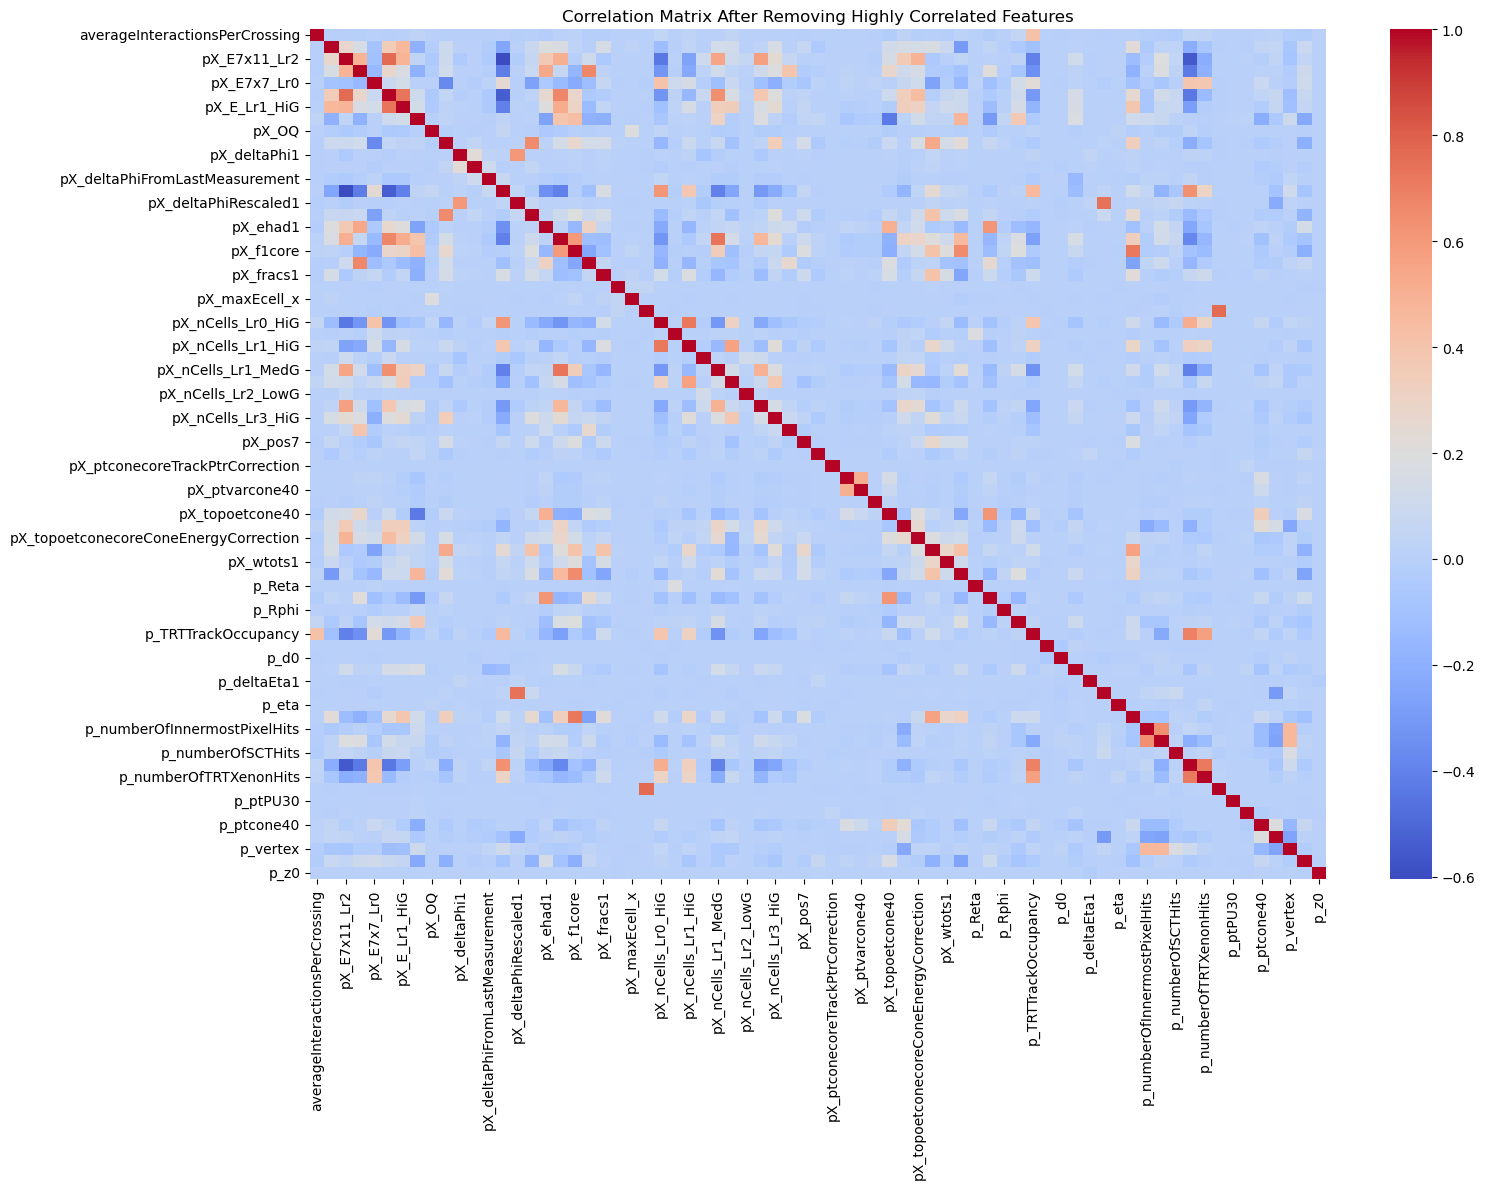

In [345]:
# Calculate correlation matrix
corr_matrix = X.corr().abs()

# Create mask for upper triangle of correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

# Find features with correlation > 0.8
to_drop = [c for c in tri_df.columns if any(tri_df[c] > 0.8)]

# Optional: visualize correlations for selected features
plt.figure(figsize=(16, 12))
sns.heatmap(X[X.columns.difference(to_drop)].corr(), 
            annot=False, cmap='coolwarm')
plt.title('Correlation Matrix After Removing Highly Correlated Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png')


## Data Normalization and Standardization

In [328]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Standard scaling (zero mean, unit variance)
standard_scaler = StandardScaler()
X_std_scaled = standard_scaler.fit_transform(X)


# # Min-max scaling (to [0,1] range)
# minmax_scaler = MinMaxScaler()
# X_minmax_scaled = minmax_scaler.fit_transform(X)

# Robust scaling (using quantiles, less sensitive to outliers)
robust_scaler = RobustScaler()
X_robust_scaled = robust_scaler.fit_transform(X)



X_scaled_selector = X_robust_scaled #X_std_scaled

# Convert back to DataFrame to preserve column names and index
X_scaled = pd.DataFrame(X_scaled_selector, columns=X.columns, index=X.index)

X_scaled.describe()


,averageInteractionsPerCrossing,p_Rhad1,p_Rhad,p_f3,p_weta2,p_Rphi,p_Reta,p_Eratio,p_f1,p_TRTPID,...,pX_E7x11_Lr0,pX_E7x11_Lr1,pX_E7x11_Lr2,pX_E7x11_Lr3,pX_E7x7_Lr0,pX_E7x7_Lr1,p_pt_track,p_eta,p_phi,p_charge
count,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,...,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,-0.021267,0.374513,0.349044,0.798644,0.113884,-0.134374,0.517192,0.029955,-0.065001,0.055664,...,0.365596,0.346797,0.397673,0.708763,0.366880,0.348009,0.384552,-0.001853,0.005058,-0.495933
std,0.685090,1.069800,1.020824,2.399245,1.137039,5.927452,277.405938,0.502433,0.749125,1.077355,...,1.023639,1.131764,1.217123,2.030350,1.026903,1.133873,16.694817,0.595616,0.578776,0.499985
min,-2.251407,-1.508830,-1.134240,-1.213774,-21.154085,-941.498634,-3567.399044,-0.681299,-8.641344,-4.333378,...,-1.412363,-2.109980,-1.050984,-1.070962,-1.426275,-2.110875,-0.731157,-1.146504,-0.995531,-1.000000
25%,-0.500313,-0.331567,-0.342447,-0.230691,-0.455414,-0.565160,-0.542544,-0.446704,-0.531593,-0.552172,...,-0.317556,-0.360385,-0.336650,-0.243023,-0.318796,-0.359957,-0.389381,-0.502813,-0.495625,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.499687,0.668433,0.657553,0.769309,0.544586,0.434840,0.457456,0.553296,0.468407,0.447828,...,0.682444,0.639615,0.663350,0.756977,0.681204,0.640043,0.610619,0.497187,0.504375,0.000000
max,1.438399,34.667173,33.165295,44.717108,20.340887,1972.569833,117604.398194,0.758023,3.292226,12.395003,...,27.123947,20.729385,26.537189,63.698906,27.506383,20.867288,6207.482027,1.136550,1.015457,0.000000


## Feature Importance Methods

### For Classification Task:

In [329]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
import time

start=time.time()

# Split data set into training and test set. We choose a 75:25 division here. 

# Dataset is shuffeled before the split (to avoid any ordering). By using a fixed
# random seed number (42), we can rerun and obtain the same result (for reproducibility!).
X_train, x_test, Y_train, y_test = \
    train_test_split(X_scaled, y_class, test_size=0.25, random_state=42)

# Feed the datasets to LightGBM:
lgb_train = lgb.Dataset(X_train, Y_train)
lgb_eval  = lgb.Dataset(x_test,  y_test, reference=lgb_train)

# Set parameters for LightGBM (known more generally as "hyper parameters"):
params = {
    'boosting_type': 'gbdt', # Traditional Gradient Boosting tree, we are combining many 'weak' learners here!
    'objective': 'binary',   # The outcome is binary, b-quark or not
    'num_leaves': 10,         # Set a maximum tree leaves to avoid overfitting
    'verbose': 1,            # Level of output. Can be set to -1 to suppress the output
}

# Train the model:
gbm = lgb.train(params,                             # General settings (defined above)
                lgb_train,                          # Data to use for training
                num_boost_round=100_000,               # How many rounds for training
                valid_sets=lgb_eval,                # Data to use for validation
                callbacks=[early_stopping(1_000)])     # Stops if no improvement is seen in N=20 rounds.

# Make predictions.
# NOTE the difference between 'score' (continuous in ]0,1[) and 'predictions' (integer: 0 or 1):
# Also NOTE that you can choose where to set the threshold (here set to 0.1)
y_score = gbm.predict(x_test, num_iteration=gbm.best_iteration)  # Scores are floats in the range ]0,1[.
y_pred  = [1 if pred > 0.1 else 0 for pred in y_score]               # Classify b-quark yes or no (for comparison). 

# Print the time usage:
end = time.time()
print(f"Time used by LightGBM: {(end-start)*1000:.1f} ms")

[LightGBM] [Info] Number of positive: 28466, number of negative: 106534
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29740
[LightGBM] [Info] Number of data points in the train set: 135000, number of used features: 138
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.210859 -> initscore=-1.319754
[LightGBM] [Info] Start training from score -1.319754
Training until validation scores don't improve for 1000 rounds
Early stopping, best iteration is:
[1078]	valid_0's binary_logloss: 0.0649714
Time used by LightGBM: 12823.7 ms


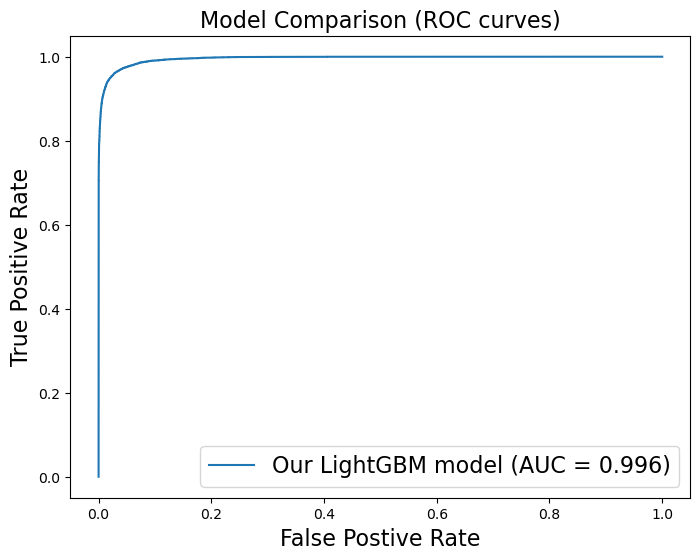

In [330]:
# Evaluate:
fpr, tpr, _ = roc_curve(y_test, y_score)  # False/True Positive Rate for our model

# We can now calculate the Area-Under-the-Curve (AUC) scores of these ROC-curves:
auc_score = auc(fpr,tpr)      # This is the AUC score for our model

# Let's plot the ROC curves for these results:
fig = plt.figure(figsize = [8,6])
plt.title('Model Comparison (ROC curves)', size = 16)
plt.plot(fpr, tpr, label=f'Our LightGBM model (AUC = {auc_score:5.3f})')
plt.legend(fontsize=16)
plt.xlabel('False Postive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.show()

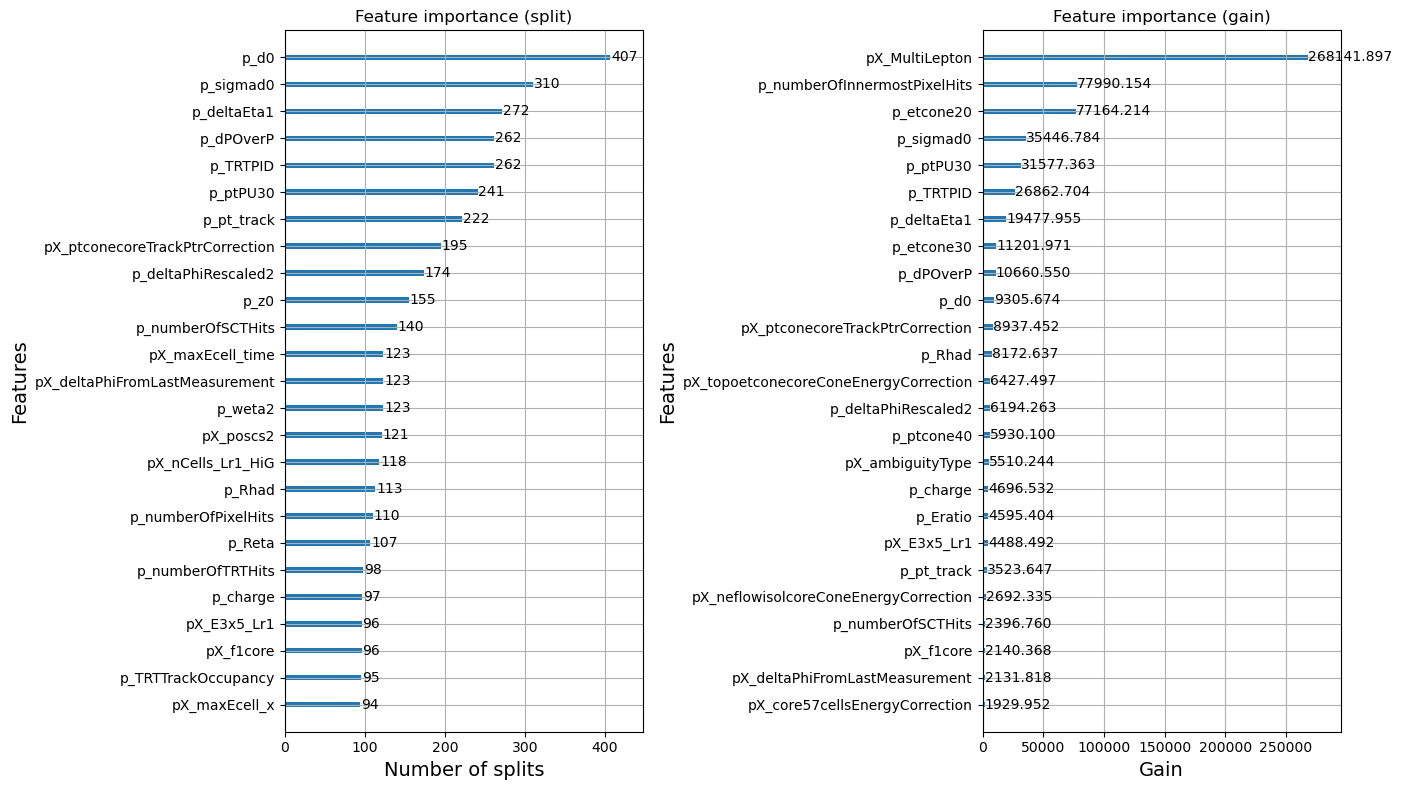

In [331]:
# Feature ranking in LightGBM:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Plot importance by split
lgb.plot_importance(gbm, max_num_features=25, importance_type='split', ax=axes[0], title='Feature importance (split)')
axes[0].set_xlabel('Number of splits', size=14)
axes[0].set_ylabel('Features', size=14)

# Plot importance by gain
lgb.plot_importance(gbm, max_num_features=25, importance_type='gain', ax=axes[1], title='Feature importance (gain)')
axes[1].set_xlabel('Gain', size=14)
axes[1].set_ylabel('Features', size=14)

plt.tight_layout()
plt.show()

In [332]:
from pandas import DataFrame


importances_split = gbm.feature_importance('split')
importances_gain = gbm.feature_importance('gain')
feature_names = gbm.feature_name()

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_split': importances_split,
    'Importance_gain': importances_gain,    
}).sort_values(by='Importance_gain', ascending=False)

# Get top 5 by each metric
top5_gain = feature_imp_df.sort_values(by='Importance_gain', ascending=False).head(7)
top5_split = feature_imp_df.sort_values(by='Importance_split', ascending=False).head(3)

# Combine and drop duplicates while preserving order
combined_top = pd.concat([top5_gain, top5_split]).drop_duplicates(subset='Feature', keep='first')

# Optional: reset index for clean printing
combined_top = combined_top.reset_index(drop=True)

# Display the result
print("Combined top features (top n by gain ∪ top m by split):")
display(combined_top)


Combined top features (top n by gain ∪ top m by split):


,Feature,Importance_split,Importance_gain
0,pX_MultiLepton,47,268141.896627
1,p_numberOfInnermostPixelHits,93,77990.154379
2,p_etcone20,64,77164.214367
3,p_sigmad0,310,35446.784064
4,p_ptPU30,241,31577.363219
5,p_TRTPID,262,26862.704354
6,p_deltaEta1,272,19477.955332
7,p_d0,407,9305.674345


/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


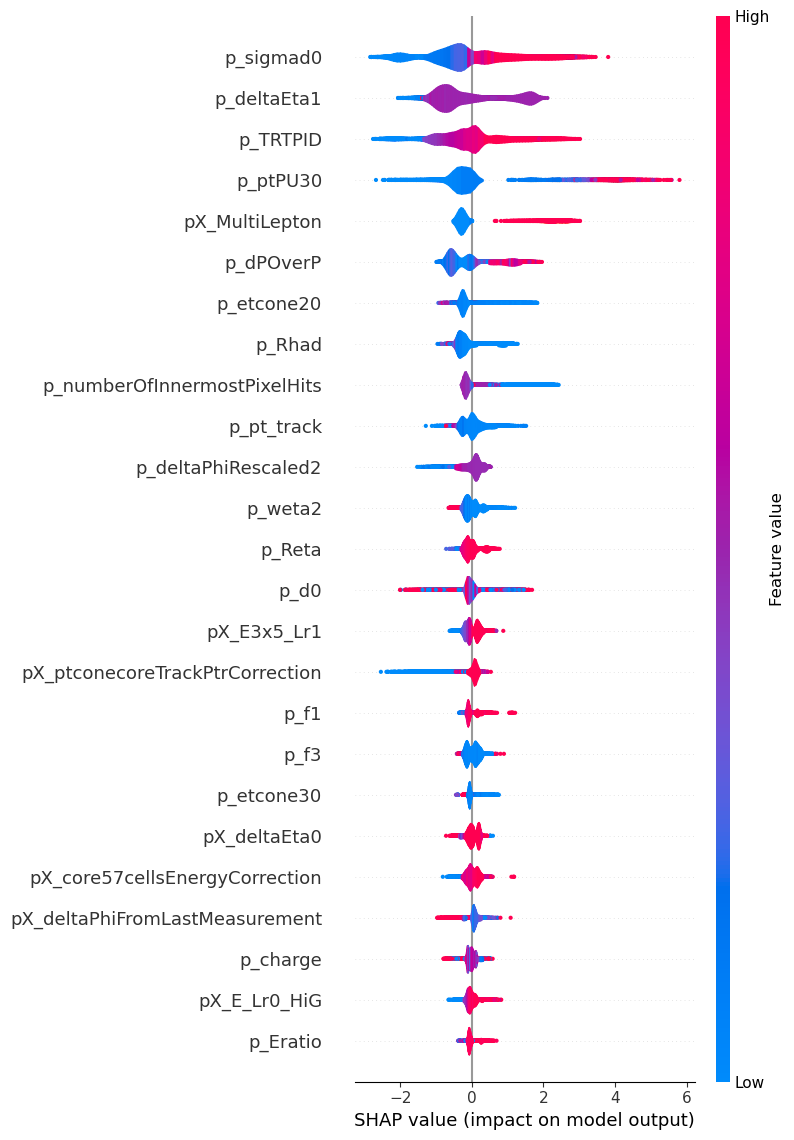

In [333]:
import shap

# For classification
explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(x_test)  # Sample for speed

shap.summary_plot(shap_values, x_test, feature_names=input_variables, plot_type="violin", max_display=25)
plt.show()

shap_sum = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame([X.columns, shap_sum]).T
importance_df.columns = ['feature', 'shap_importance']
importance_df = importance_df.sort_values('shap_importance', ascending=False)
shap_top25_features = importance_df.copy().head(25)['feature'].tolist()

### retraining with top features

In [340]:
# Make new selections based on top 5/10 variables
# top_5_features  = feature_imp_df.Feature[:8]
top_5_features  = shap_top25_features[:8]

# top_10_features  = feature_imp_df.Feature[:10]
top_10_features  = combined_top.Feature



input_top_5 = X[top_5_features]
input_top_10 = X[top_10_features]


# Train and evaluate the model using the top 5 variables
X_train_top_5, x_test_top_5, Y_train_top_5, y_test_top_5 = \
    train_test_split(input_top_5, y_class, test_size=0.25, random_state=42)

lgb_train_top_5 = lgb.Dataset(X_train_top_5, Y_train_top_5)
lgb_eval_top_5 = lgb.Dataset(x_test_top_5, y_test_top_5, reference=lgb_train_top_5)

gbm_top_5 = lgb.train(params, lgb_train_top_5, num_boost_round=50_000, valid_sets=lgb_eval_top_5, callbacks=[early_stopping(1_000)])

y_score_top_5 = gbm_top_5.predict(x_test_top_5, num_iteration=gbm_top_5.best_iteration)
y_pred_top_5 = [1 if pred > 0.1 else 0 for pred in y_score_top_5]



# Train and evaluate the model using the bottom 5 variables
X_train_top_10, x_test_top_10, Y_train_top_10, y_test_top_10 = \
    train_test_split(input_top_10, y_class, test_size=0.25, random_state=42)

lgb_train_top_10 = lgb.Dataset(X_train_top_10, Y_train_top_10)
lgb_eval_top_10 = lgb.Dataset(x_test_top_10, y_test_top_10, reference=lgb_train_top_10)

gbm_top_10 = lgb.train(params, lgb_train_top_10, num_boost_round=50_000, valid_sets=lgb_eval_top_10, callbacks=[early_stopping(1_000)])

y_score_top_10 = gbm_top_10.predict(x_test_top_10, num_iteration=gbm_top_10.best_iteration)
y_pred_top_10 = [1 if pred > 0.1 else 0 for pred in y_score_top_10]


# Print results
print("Model trained with top 5 variables:")
print(f"AUC Score: {auc(roc_curve(y_test_top_5, y_score_top_5)[0], roc_curve(y_test_top_5, y_score_top_5)[1]):.3f}")

print("\nModel trained with top 10 variables:")
print(f"AUC Score: {auc(roc_curve(y_test_top_10, y_score_top_10)[0], roc_curve(y_test_top_10, y_score_top_10)[1]):.3f}")

[LightGBM] [Info] Number of positive: 28466, number of negative: 106534
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1787
[LightGBM] [Info] Number of data points in the train set: 135000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.210859 -> initscore=-1.319754
[LightGBM] [Info] Start training from score -1.319754
Training until validation scores don't improve for 1000 rounds
Early stopping, best iteration is:
[307]	valid_0's binary_logloss: 0.104738
[LightGBM] [Info] Number of positive: 28466, number of negative: 106534
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Lig

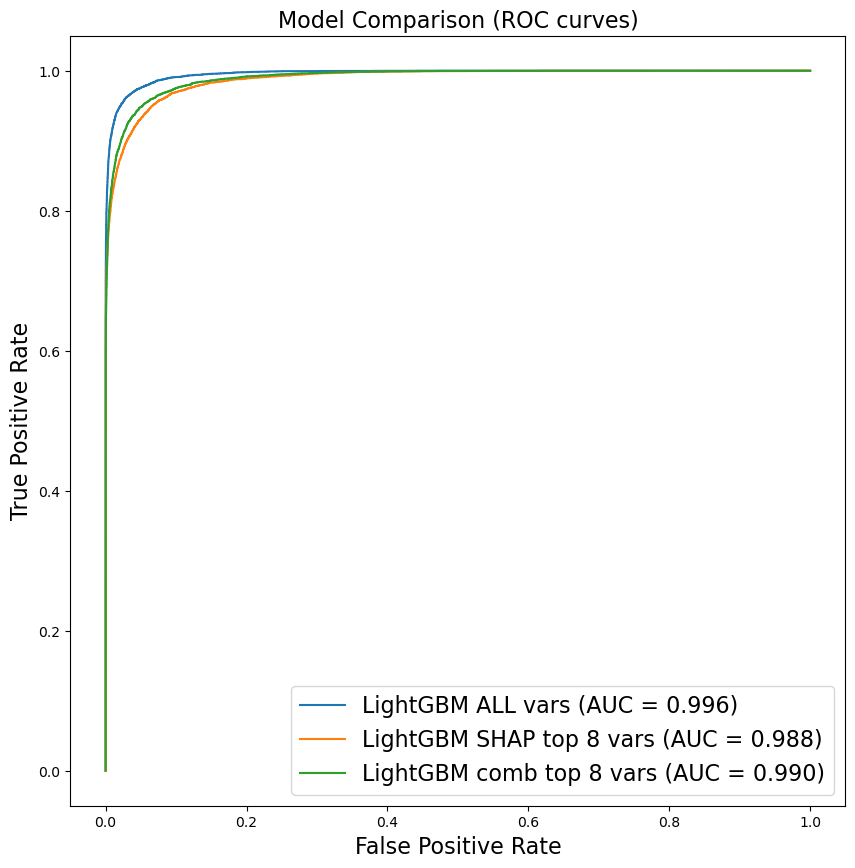

In [342]:
# Evaluate bottom / top 5
fpr_top_5, tpr_top_5, _ = roc_curve(y_test_top_5, y_score_top_5)
fpr_top_10, tpr_top_10, _ = roc_curve(y_test_top_10, y_score_top_10)

# We can now calculate the Area-Under-the-Curve (AUC) scores of these ROC-curves:
auc_score_top_5 = auc(fpr_top_5, tpr_top_5)                        # This is the AUC score for the top 5 model
auc_score_top_10 = auc(fpr_top_10, tpr_top_10)              # This is the AUC score for the bottom 5 model

# Let's plot the ROC curves for these results:
fig = plt.figure(figsize=[10, 10])
plt.title('Model Comparison (ROC curves)', size=16)
plt.plot(fpr, tpr, label=f'LightGBM ALL vars (AUC = {auc_score:5.3f})')
plt.plot(fpr_top_5, tpr_top_5, label=f'LightGBM SHAP top 8 vars (AUC = {auc_score_top_5:5.3f})')
# plt.plot(fpr_top_10, tpr_top_10, label=f'LightGBM model using top 10 variables (AUC = {auc_score_top_10:5.3f})')
plt.plot(fpr_top_10, tpr_top_10, label=f'LightGBM comb top 8 vars (AUC = {auc_score_top_10:5.3f})')
plt.legend(fontsize=16)
plt.xlabel('False Positive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.show()


### Save the processed datasets for model training

In [ ]:
# # Create final training datasets
# X_train_classification = X_filtered[top_25_features_clf]
# y_train_classification = y_classification

# X_train_regression = X_filtered[top_12_features_reg][y_classification == 1]
# y_train_regression = y_regression[y_classification == 1]

# X_train_clustering = X_filtered[top_7_features]

# # Save these datasets for next phase
# X_train_classification.to_parquet('processed_classification_features.parquet')
# pd.Series(y_train_classification).to_parquet('processed_classification_target.parquet')

# X_train_regression.to_parquet('processed_regression_features.parquet')
# pd.Series(y_train_regression).to_parquet('processed_regression_target.parquet')

# X_train_clustering.to_parquet('processed_clustering_features.parquet')

# # Save feature lists for application to test data
# pd.Series(top_25_features_clf).to_csv('classification_features.csv', index=False)
# pd.Series(top_12_features_reg).to_csv('regression_features.csv', index=False)
# pd.Series(top_7_features).to_csv('clustering_features.csv', index=False)

# # Save scalers for application to test data
# import pickle
# with open('classification_scaler.pkl', 'wb') as f:
#     pickle.dump(standard_scaler, f)


In [ ]:
# # Load test datasets
# df_test_clf = pd.read_parquet('AppML_InitialProject_test_classification.parquet.gz')
# df_test_reg = pd.read_parquet('AppML_InitialProject_test_regression.parquet.gz')

# # Apply feature selection to test data
# X_test_classification = df_test_clf[top_25_features_clf]
# X_test_regression = df_test_reg[top_12_features_reg]

# # Apply scaling
# X_test_classification_scaled = standard_scaler.transform(X_test_classification)
# X_test_regression_scaled = standard_scaler.transform(X_test_regression)

# # Save processed test data
# pd.DataFrame(X_test_classification_scaled).to_parquet('processed_test_classification.parquet')
# pd.DataFrame(X_test_regression_scaled).to_parquet('processed_test_regression.parquet')


## Create Pipeline

In [ ]:
from sklearn.pipeline import Pipeline

# Classification pipeline
classification_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the data
    ('classifier', None)  # To be filled with actual classifier
])



In [ ]:
# 4. Define preprocessing for numeric (and categorical if any)
numeric_feats = combined_top.Feature
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])


## Training

## Fit & evaluate